#  Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score


# Load Data and Basic Cleaning

In [2]:

# Load the CSV
# df = pd.read_csv("SaleFactDataQueary.csv")
df = pd.read_csv('D:\BI_NI_CI\ModelAllData2.csv')

# Basic cleaning
df['Miladi'] = pd.to_datetime(df['Miladi'], errors='coerce')
df = df.dropna(subset=['Miladi', 'GoodsID', 'MainQty'])

# Ensure numeric quantity
df['MainQty'] = pd.to_numeric(df['MainQty'], errors='coerce').fillna(0)


<>:3: SyntaxWarning: invalid escape sequence '\B'
<>:3: SyntaxWarning: invalid escape sequence '\B'
C:\Users\M Zafar\AppData\Local\Temp\ipykernel_1272\1197775482.py:3: SyntaxWarning: invalid escape sequence '\B'
  df = pd.read_csv('D:\BI_NI_CI\ModelAllData2.csv')
C:\Users\M Zafar\AppData\Local\Temp\ipykernel_1272\1197775482.py:3: DtypeWarning: Columns (11,15,16,17,18,19,23,25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('D:\BI_NI_CI\ModelAllData2.csv')


# Feature Engineering

## Basics

In [3]:

# Feature engineering (daily level)
df['year'] = df['Miladi'].dt.year
df['month'] = df['Miladi'].dt.month
df['quarter'] = df['Miladi'].dt.quarter

# convert IsHoliday to numeric
df['IsHoliday'] = df['IsHoliday'].astype(int)

## Aggregates

In [4]:
# Aggregate per month per GoodsID
monthly = (
    df.groupby(['GoodsID', 'year', 'month', 'quarter'], as_index=False)
      .agg({'MainQty': 'sum', 'Price': 'mean'})
)

# Create a proper datetime for each month (using first day of month)
monthly['date'] = pd.to_datetime(monthly[['year', 'month']].assign(day=1))

# Add missing months
# global min/max date
min_date = monthly['date'].min()
max_date = monthly['date'].max()

full_months = pd.date_range(min_date, max_date, freq='MS')

# cartesian product (fast)
full_index = (
    pd.MultiIndex.from_product(
        [monthly['GoodsID'].unique(), full_months],
        names=['GoodsID', 'date']
    )
)

monthly_full = (
    monthly.set_index(['GoodsID','date'])
           .reindex(full_index)
           .reset_index()
)

monthly_full['MainQty'] = monthly_full['MainQty'].fillna(0)
monthly_full['Price']   = monthly_full['Price'].fillna(0)   # or keep NaN
monthly_full['year']    = monthly_full['date'].dt.year
monthly_full['month']   = monthly_full['date'].dt.month
monthly_full['quarter'] = monthly_full['date'].dt.quarter


# Create lag features
monthly_full  = monthly_full .sort_values(['GoodsID', 'date'])

# 24 months Lags
LAGS = list(range(1,25))
lag_features=[]
for lag in LAGS:
    monthly_full [f'lag_{lag}'] = monthly_full .groupby('GoodsID')['MainQty'].shift(lag)
    lag_features.append(f'lag_{lag}')

# Rolling features
ROLLINGS = [3,6,9,12]
rolling_features=[]
for rol in ROLLINGS:
    monthly_full [f'rolling_{rol}'] = (
        monthly_full .groupby('GoodsID')['MainQty']
        .transform(lambda x: x.shift(1).rolling(rol).mean())
    )
    rolling_features.append(f'rolling_{rol}')

# Drop rows with all null features
monthly_full  = monthly_full .dropna(how='all', subset=lag_features + rolling_features).reset_index(drop=True)

all_features = lag_features + rolling_features + ['Price', 'year', 'month', 'quarter']

In [5]:
monthly=monthly_full.copy()

In [6]:
monthly_full

,GoodsID,date,year,month,quarter,MainQty,Price,lag_1,lag_2,lag_3,...,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rolling_3,rolling_6,rolling_9,rolling_12
0,50608,2022-07-01,2022,7,3,0.0,0.0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,50608,2022-08-01,2022,8,3,0.0,0.0,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,50608,2022-09-01,2022,9,3,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
3,50608,2022-10-01,2022,10,4,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
4,50608,2022-11-01,2022,11,4,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
965217,80476,2025-07-01,2025,7,3,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
965218,80476,2025-08-01,2025,8,3,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
965219,80476,2025-09-01,2025,9,3,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
965220,80476,2025-10-01,2025,10,4,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


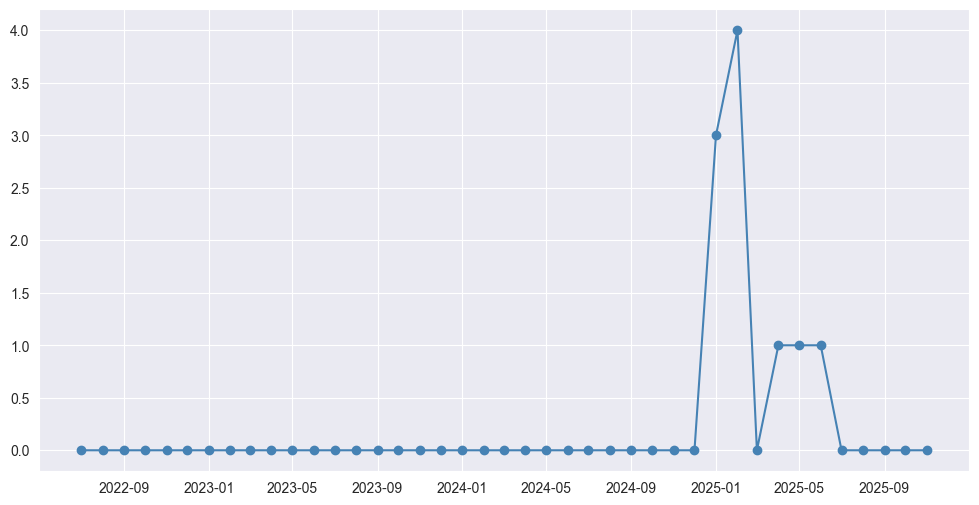

In [7]:
ss=monthly_full[monthly_full['GoodsID']==monthly_full[['GoodsID']].sample(1).iloc[0,0]]
# ss=monthly_full[monthly_full['GoodsID']==61590]

plt.figure(figsize=(12,6))

    # Actual sales (ground truth)
plt.plot(
    ss['date'],
    ss['MainQty'],
    label='Actual Sales',
    marker='o',
    color='steelblue',
)


In [8]:
ss

,GoodsID,date,year,month,quarter,MainQty,Price,lag_1,lag_2,lag_3,...,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rolling_3,rolling_6,rolling_9,rolling_12
365515,60410,2022-07-01,2022,7,3,0.0,0.0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
365516,60410,2022-08-01,2022,8,3,0.0,0.0,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
365517,60410,2022-09-01,2022,9,3,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
365518,60410,2022-10-01,2022,10,4,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
365519,60410,2022-11-01,2022,11,4,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
365520,60410,2022-12-01,2022,12,4,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN
365521,60410,2023-01-01,2023,1,1,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN
365522,60410,2023-02-01,2023,2,1,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN
365523,60410,2023-03-01,2023,3,1,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN
365524,60410,2023-04-01,2023,4,2,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN


In [9]:
monthly.GoodsID.nunique()

23542

# Train/Test Split

In [10]:
# Prepare training data
# Features: lag, rolling stats, price, year, month, quarter
feature_cols = all_features
X = monthly[feature_cols]
y = monthly['MainQty']

# Train/test split (chronological)
# last 2 months as test
split_date = monthly['date'].max() - pd.DateOffset(months=2)
train_idx = monthly['date'] <= split_date
test_idx = monthly['date'] > split_date

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Model training and Hyperparameter Tuning

In [11]:
tscv = TimeSeriesSplit(n_splits=3)

xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.03, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=3
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)


# Fitting 3 folds for each of 108 candidates, totalling 324 fits
# Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 7, 'n_estimators': 300, 'subsample': 1.0}


# Evaluation

In [12]:
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")


# MAE: 3.82
# RMSE: 10.62
# R²: 0.790

MAE: 1.43
RMSE: 8.37
R²: 0.628


In [13]:
best_model.save_model('xgb_1.42.json')

# Forcast Next Month

In [14]:

# Forecast for each GoodsID for the next month
latest_date = monthly['date'].max()
forecast_month = latest_date + pd.DateOffset(months=1)

latest_features = (
    monthly.sort_values(['GoodsID', 'date'])
    .groupby('GoodsID')
    .tail(1)[['GoodsID'] + feature_cols]
)

latest_features['forecast_month'] = forecast_month
latest_features['predicted_next_month'] = best_model.predict(latest_features[feature_cols])

latest_features[['GoodsID', 'forecast_month', 'predicted_next_month']]


,GoodsID,forecast_month,predicted_next_month
40,50608,2025-12-01,0.116793
81,50609,2025-12-01,37.423386
122,50610,2025-12-01,0.158851
163,50611,2025-12-01,3.354522
204,50612,2025-12-01,-0.047123
...,...,...,...
965057,80426,2025-12-01,2.473068
965098,80429,2025-12-01,2.556056
965139,80436,2025-12-01,2.557889
965180,80472,2025-12-01,2.596823


In [15]:
def plot_historical_and_predictions(target_goodsid):

    # Prepare historical + prediction data
    product_df = monthly[monthly['GoodsID'] == target_goodsid].copy()
    product_df = product_df.sort_values('date')

    # Predict on all available months
    product_df['predicted'] = best_model.predict(product_df[feature_cols])

    # Prepare next-month forecast (if available)
    forecast_row = latest_features[latest_features['GoodsID'] == target_goodsid]

    # Plot
    plt.figure(figsize=(12,6))

    # Actual sales (ground truth)
    plt.plot(
        product_df['date'],
        product_df['MainQty'],
        label='Actual Sales',
        marker='o',
        color='steelblue',
    )

    # Model predictions (train + test)
    plt.plot(
        product_df['date'],
        product_df['predicted'],
        label='Model Prediction',
        linestyle='--',
        marker='.',
        color='orange',
    )

    # Add forecast for next month (if available)
    if not forecast_row.empty:
        plt.scatter(
            forecast_row['forecast_month'],
            forecast_row['predicted_next_month'],
            color='red',
            s=120,
            marker='*',
            label='Next Month Forecast'
        )

    # Visual split marker
    plt.axvline(split_date, color='gray', linestyle=':', label='Train/Test Split')

    # Labels and formatting
    plt.title(f"GoodsID {target_goodsid} — Historical, Predicted, and Forecasted Sales")
    plt.xlabel("Date")
    plt.ylabel("Sales Quantity")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


GoodId = 66010


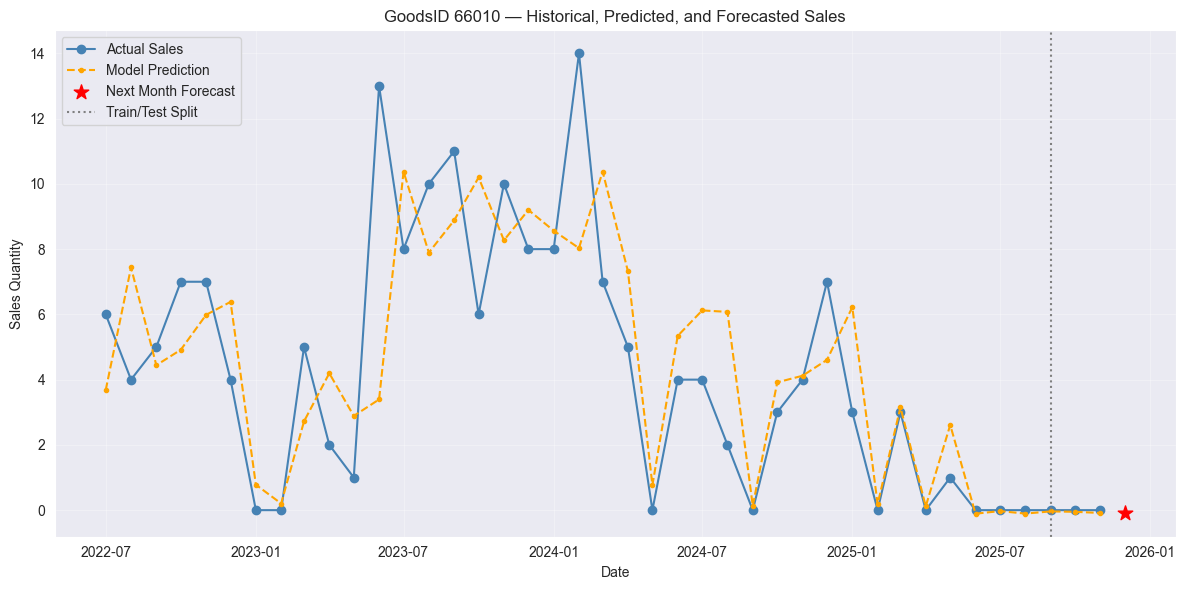

In [72]:
good_id = monthly[~monthly['lag_8'].isna()].sample(1).iloc[0,0]
print(f'GoodId = {good_id}')
plot_historical_and_predictions(good_id)